# NOTEBOOK TO GENERATE NYUD DATASET

In [1]:
import glob
import cv2

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
import os
from pymatreader import read_mat


%load_ext autotime

time: 864 µs (started: 2024-12-02 15:44:56 -05:00)


### Loading data from .mat file

In [8]:
filename = "../data/nyu.mat"

data = None
# Open the .mat file
with h5py.File(filename , "r") as mat_file:
    data = {key: np.array(mat_file[key]) for key in mat_file.keys()}
    
    # Inspect the keys
    print("Keys in the file:", list(mat_file.keys()))

    # Access a dataset
    images = mat_file['images']  # Replace 'images' with the actual key in your file
    depths = mat_file['depths']  # Replace with actual key
    
    # Convert datasets to NumPy arrays
    images = images[()]  # If images is a dataset, this retrieves it as a NumPy array
    depths = depths[()]

Keys in the file: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
time: 1min 15s (started: 2024-11-30 23:23:34 -05:00)


In [3]:
print(data.keys())

dict_keys(['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes'])
time: 527 µs (started: 2024-11-30 20:10:38 -05:00)


In [2]:
import pickle

sub_mat = {"images": data['images'], "instances": data['instances'], "labels": data['labels']}

with open('../resources/sub_mat.pkl', 'wb') as f:
    pickle.dump(sub_mat, f, protocol=pickle.HIGHEST_PROTOCOL)

NameError: name 'data' is not defined

time: 99.4 ms (started: 2024-12-02 15:45:02 -05:00)


In [62]:
filename = "../data/nyu.mat"
names = read_mat(filename, variable_names=['names'])

time: 91.8 ms (started: 2024-12-02 16:20:04 -05:00)


In [65]:
print(np.array(names["names"]))

['book' 'bottle' 'cabinet' 'ceiling' 'chair' 'cone' 'counter' 'dishwasher'
 'faucet' 'fire extinguisher' 'floor' 'garbage bin' 'microwave'
 'paper towel dispenser' 'paper' 'pot' 'refridgerator' 'stove burner'
 'table' 'unknown' 'wall' 'bowl' 'magnet' 'sink' 'air vent' 'box'
 'door knob' 'door' 'scissor' 'tape dispenser' 'telephone cord'
 'telephone' 'track light' 'cork board' 'cup' 'desk' 'laptop' 'air duct'
 'basket' 'camera' 'pipe' 'shelves' 'stacked chairs' 'styrofoam object'
 'whiteboard' 'computer' 'keyboard' 'ladder' 'monitor' 'stand' 'bar'
 'motion camera' 'projector screen' 'speaker' 'bag' 'clock' 'green screen'
 'mantel' 'window' 'ball' 'hole puncher' 'light' 'manilla envelope'
 'picture' 'mail shelf' 'printer' 'stapler' 'fax machine' 'folder' 'jar'
 'magazine' 'ruler' 'cable modem' 'fan' 'file' 'hand sanitizer'
 'paper rack' 'vase' 'air conditioner' 'blinds' 'flower' 'plant' 'sofa'
 'stereo' 'books' 'exit sign' 'room divider' 'bookshelf' 'curtain'
 'projector' 'modem' 'wire' 

In [53]:
with open('../resources/sub_nyu_mat.pkl', 'rb') as f:
    sub_mat_loaded = pickle.load(f)

time: 486 ms (started: 2024-12-02 16:18:15 -05:00)


In [54]:
print(sub_mat_loaded.keys())

dict_keys(['images', 'instances', 'labels'])
time: 278 µs (started: 2024-12-02 16:18:17 -05:00)


In [55]:
print(np.shape(sub_mat_loaded["images"]))

(1449, 3, 640, 480)
time: 586 µs (started: 2024-12-02 16:18:17 -05:00)


In [56]:
print(sub_mat_loaded["images"].dtype)

uint8
time: 545 µs (started: 2024-12-02 16:18:18 -05:00)


In [57]:
from glob import glob
hha_image_paths = glob(os.path.join("/Users/ajay/Documents/NEU_Academics/Sem-1/Computer_Vision/Group_Project/NYUD/hha", "*.png"))
print(hha_image_paths[0])

/Users/ajay/Documents/NEU_Academics/Sem-1/Computer_Vision/Group_Project/NYUD/hha/348.png
time: 6.59 ms (started: 2024-12-02 16:18:18 -05:00)


In [58]:
from PIL import Image

hha_images = []
for path in hha_image_paths:
    image = Image.open(path)
    image = np.array(image).transpose(2, 1, 0)
    hha_images.append(image)
hha_images = np.array(hha_images)
print(hha_images.shape)

(1449, 3, 640, 480)
time: 10.3 s (started: 2024-12-02 16:18:19 -05:00)


In [66]:
with open('../resources/sub_nyu_mat.pkl', 'rb') as f:
    sub_mat_loaded = pickle.load(f)
    sub_mat_loaded['hha'] = hha_images
    sub_mat_loaded['names'] = np.array(names["names"])
    with open('../resources/sub_nyu_hha_mat.pkl', 'wb') as f:
        pickle.dump(sub_mat_loaded, f, protocol=pickle.HIGHEST_PROTOCOL)

time: 2.58 s (started: 2024-12-02 16:21:09 -05:00)


In [43]:
sub_mat_loaded = None
with open('../resources/sub_nyu_hha_mat.pkl', 'rb') as f:
    sub_mat_loaded = pickle.load(f)

time: 1.32 s (started: 2024-12-02 16:05:11 -05:00)


In [44]:
print(sub_mat_loaded.keys())

dict_keys(['images', 'instances', 'labels', 'hha'])
time: 694 µs (started: 2024-12-02 16:05:27 -05:00)


In [45]:
hha = sub_mat_loaded['hha']
print(hha.shape)

(1449, 3, 640, 480)
time: 215 µs (started: 2024-12-02 16:05:37 -05:00)


(480, 640, 3)


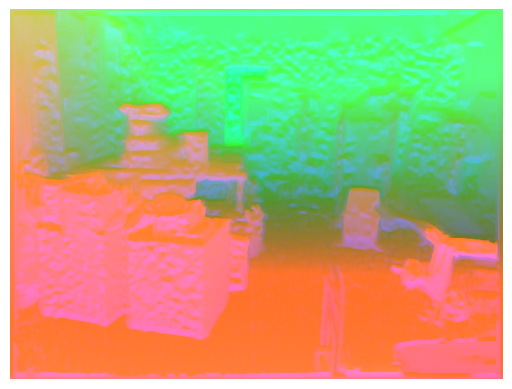

time: 113 ms (started: 2024-12-02 16:07:34 -05:00)


In [52]:
img = np.rot90(hha[0].transpose(1, 2, 0), k=-1)
print(img.shape)
plt.axis(False)
plt.imshow(img)

In [9]:
print(f"Total number of images: {images.shape}")
print(f"Total number of labels: {depths.shape}")

Total number of images: (1449, 3, 640, 480)
Total number of labels: (1449, 640, 480)
time: 257 µs (started: 2024-11-26 23:42:51 -05:00)


### Visualize a depth map

In [12]:
print(depths[0].shape)

(640, 480)
time: 331 µs (started: 2024-11-26 23:43:20 -05:00)


In [13]:
print(np.rot90(depths[0], k=-1).shape)

(480, 640)
time: 399 µs (started: 2024-11-26 23:43:22 -05:00)


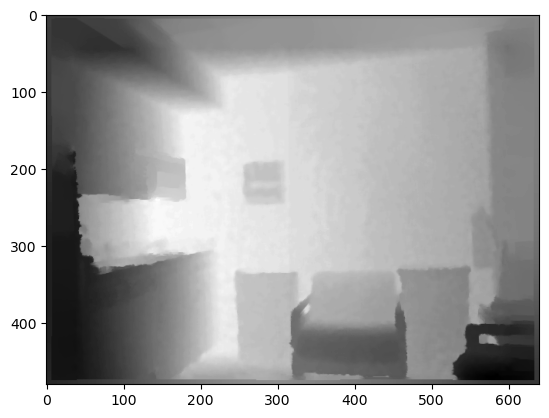

time: 114 ms (started: 2024-11-26 23:43:33 -05:00)


In [15]:
image = np.rot90(depths[0], k=-1)

plt.imshow(image, cmap="gray")

In [16]:
depth_map_tensor = torch.Tensor(depths)
print(depth_map_tensor.shape)

torch.Size([1449, 640, 480])
time: 2.48 ms (started: 2024-11-26 23:43:44 -05:00)


### Save depth values as tensors, just for a reference

In [9]:
torch.save(depth_map_tensor, "./depth_map.pth")

### Store depth maps as 16-bit PNG format images

In [17]:
print(type(depths))

<class 'numpy.ndarray'>
time: 323 µs (started: 2024-11-26 23:43:56 -05:00)


In [63]:
for idx in tqdm(range(depths.shape[0])): 
    depth_map = np.fliplr( np.rot90(depths[idx], k=-1))
    # depth_map = depths[idx]
    normalized_depth_map = np.uint16((depth_map - np.min(depth_map))/(np.max(depth_map) - np.min(depth_map)) * 65535)
    depth_image = Image.fromarray(normalized_depth_map)
    depth_image.save(f"../../NYUD/depth/{idx}.png")

print("All depth maps saved as png images!")

100%|██████████| 1449/1449 [01:28<00:00, 16.31it/s]

All depth maps saved as png images!
time: 1min 28s (started: 2024-11-27 00:49:01 -05:00)


### Raw Depth Maps

In [26]:
filename = "../data/nyu.mat"

# Open the .mat file
with h5py.File(filename , "r") as mat_file:
    # Inspect the keys
    print("Keys in the file:", list(mat_file.keys()))

    # Access a dataset
    images = mat_file['images']  # Replace 'images' with the actual key in your file
    raw_depths = mat_file['rawDepths']  # Replace with actual key

    # Convert datasets to NumPy arrays
    images = images[()]  # If images is a dataset, this retrieves it as a NumPy array
    raw_depths = raw_depths[()]

Keys in the file: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
time: 23.9 s (started: 2024-11-26 23:58:53 -05:00)


In [27]:
print(f"Total number of images: {images.shape}")
print(f"Total number of rawDepths: {raw_depths.shape}")

Total number of images: (1449, 3, 640, 480)
Total number of rawDepths: (1449, 640, 480)
time: 312 µs (started: 2024-11-26 23:59:20 -05:00)


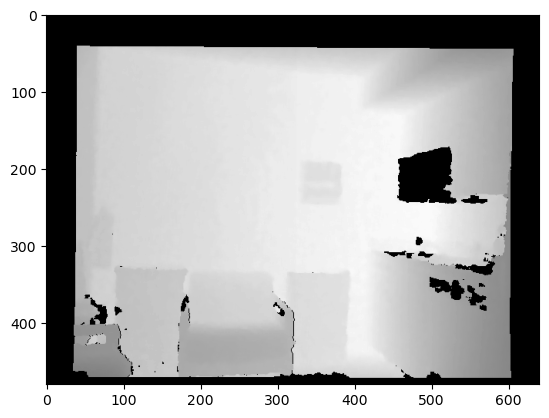

time: 123 ms (started: 2024-11-26 23:59:59 -05:00)


In [29]:
plt.imshow(np.fliplr(np.rot90(raw_depths[0], k=-1)), cmap="gray")

### Save raw depth maps as 16 bit PNG images

In [64]:
for idx in tqdm(range(raw_depths.shape[0])): 
    raw_depth_map = np.fliplr(np.rot90(raw_depths[idx], k=-1))
    # depth_map = depths[idx]
    normalized_raw_depth_map = np.uint16((raw_depth_map - np.min(raw_depth_map))/(np.max(raw_depth_map) - np.min(raw_depth_map)) * 65535)
    raw_depth_image = Image.fromarray(normalized_raw_depth_map)
    raw_depth_image.save(f"../../NYUD/raw_depth/{idx}.png")

print("All raw depth maps saved as png images!")

100%|██████████| 1449/1449 [00:52<00:00, 27.71it/s]

All raw depth maps saved as png images!
time: 52.3 s (started: 2024-11-27 00:50:50 -05:00)


### Save RGB images

In [33]:
print(images.shape)

(1449, 3, 640, 480)
time: 782 µs (started: 2024-11-27 00:08:19 -05:00)


In [34]:
print(images[0].shape)

(3, 640, 480)
time: 216 µs (started: 2024-11-27 00:09:56 -05:00)


In [65]:
for idx in tqdm(range(images.shape[0])): 
    image_array = np.fliplr(np.rot90(np.transpose(images[idx], (1, 2, 0)), k=-1))
    # depth_map = depths[idx]
    normalized_image_array = np.uint8((image_array - np.min(image_array))/(np.max(image_array) - np.min(image_array)) * 65535)
    image = Image.fromarray(normalized_image_array)
    image.save(f"../../NYUD/{idx}.png")

print("All raw depth maps saved as png images!")

100%|██████████| 1449/1449 [02:32<00:00,  9.48it/s]

All raw depth maps saved as png images!
time: 2min 32s (started: 2024-11-27 00:51:55 -05:00)


### Data Summary

In [3]:
images_dir = "../../NYUD/images"
depth_dir = "../../NYUD/depth"
raw_depth_dir = "../../NYUD/raw_depth"

total_images = len(glob.glob(os.path.join(images_dir, "*.png")))
total_depths = len(glob.glob(os.path.join(depth_dir, "*.png")))
total_raw_depths = len(glob.glob(os.path.join(raw_depth_dir, "*.png")))

print(f"Total images: {total_images}")
image = cv2.imread(os.path.join(images_dir, "0.png"))
print(f"Image shape: {image.shape}")

print(f"Total depths: {total_depths}")
depth = cv2.imread(os.path.join(depth_dir, "0.png"))
print(f"Depth map shape: {depth.shape}")

print(f"Total raw depths: {total_raw_depths}")
raw_depth = cv2.imread(os.path.join(raw_depth_dir, "0.png"))
print(f"Raw depth map shape: {raw_depth.shape}")


Total images: 1449
Image shape: (480, 640, 3)
Total depths: 1449
Depth map shape: (480, 640, 3)
Total raw depths: 1449
Raw depth map shape: (480, 640, 3)
time: 46.1 ms (started: 2024-11-27 12:08:47 -05:00)
